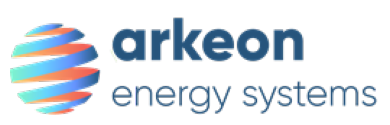

In [37]:
import pandas as pd
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

startdate = pd.Timestamp("2026-04-01")
enddate   = pd.Timestamp("2026-04-02")
nowdate = pd.Timestamp.now().normalize()

startdate_str = startdate.strftime("%Y-%m-%d")
enddate_str   = enddate.strftime("%Y-%m-%d")
nowdate_str   = nowdate.strftime("%Y-%m-%d")

generate_pdf = 0
generate_html = 1

# Display logo only
fig, ax = plt.subplots(figsize=(4, 2))

try:
    logo_path = Path('../images/logo.png')
    if logo_path.exists():
        img = mpimg.imread(logo_path)
        ax.imshow(img)
    ax.axis('off')
except:
    ax.text(0.5, 0.5, 'Logo', ha='center', va='center', fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [38]:
import ipywidgets as widgets
from IPython.display import display

# Création des cases à cocher
show_optim = widgets.Checkbox(value=True, description='Optimisation')
show_reel = widgets.Checkbox(value=True, description='Réel Site')
show_jn_site = widgets.Checkbox(value=True, description='JN Ref Site')
show_jn_optim = widgets.Checkbox(value=True, description='JN Ref Optim')

print("Sélectionnez les sources à afficher pour la suite du notebook :")
display(widgets.VBox([show_optim, show_reel, show_jn_site, show_jn_optim]))

Sélectionnez les sources à afficher pour la suite du notebook :


# Vérification et validation des modèles - visualisation

**Site :** Pervenches-Bruyères | **Système :** PAC ARKEON

In [39]:
display(Markdown(f"**Date** : {startdate_str} → {enddate_str}\n\n---"))

**Date** : 2026-04-01 → 2026-04-02

---

Acquisition (optionnel)

In [40]:
# import os
# import json
# from pathlib import Path
# import sys


# import numpy as np
# import matplotlib.pyplot as plt


# # Add project root to sys.path for module imports
# NOTEBOOKS_DIR = Path.cwd()
# PROJECT_ROOT = NOTEBOOKS_DIR.parent
# sys.path.append(str(PROJECT_ROOT))
# from src.acquisition.get_and_export_site_data_to_csv import get_and_export_site_data_to_csv

# get_and_export_site_data_to_csv(startdate)


## 1. Importation des librairies et des données

In [41]:
# CELL 1: Import Libraries and Configure Project Paths
# This cell imports all necessary libraries (pandas, numpy, matplotlib) and custom modules
# for data acquisition, API access, and pricing calculations. It also sets up the project
# root path to enable proper module imports from the src/ directory.

import os
import json
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt

# Add project root to sys.path for module imports
NOTEBOOKS_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOKS_DIR.parent
sys.path.append(str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
SITEDATA_DIR = PROJECT_ROOT / "ResultsData_site"
JUMEAUNUM_DATA_DIR = PROJECT_ROOT / "ResultsData_jumeau_num"

optim_file = DATA_DIR / "input_optimisation" / f"ResultsTable_{startdate.strftime('%d%b%y').upper()}.csv"
site_file = SITEDATA_DIR / f"ResultsTable_{startdate.strftime('%d%b%y').upper()}_site.csv"
jumeaunum_ref_optim_file = JUMEAUNUM_DATA_DIR / f"ResultsTable_{startdate.strftime('%d%b%y').upper()}_JN_ref_OPTIM.csv"
jumeaunum_ref_site_file = JUMEAUNUM_DATA_DIR / f"ResultsTable_{startdate.strftime('%d%b%y').upper()}_JN_ref_SITE.csv"

# try to load optimisation results, if missing create empty DataFrame
try:
    results_optim_detail = pd.read_csv(optim_file, sep=';')
except FileNotFoundError:
    print(f"optim file not found: {optim_file}")
    results_optim_detail = pd.DataFrame()

try:
    df_synthese_visu = pd.read_csv(site_file, sep=';')
except FileNotFoundError:
    print(f"site file not found: {site_file}")
    df_synthese_visu = pd.DataFrame()

try:
    df_jn_ref_optim = pd.read_csv(jumeaunum_ref_optim_file, sep=';')
except FileNotFoundError:
    print(f"jumeaunum optim file not found: {jumeaunum_ref_optim_file}")
    df_jn_ref_optim = pd.DataFrame()

try:
    df_jn_ref_site = pd.read_csv(jumeaunum_ref_site_file, sep=';')
except FileNotFoundError:
    print(f"jumeaunum site file not found: {jumeaunum_ref_site_file}")
    df_jn_ref_site = pd.DataFrame()

optim file not found: c:\Users\MohamadJoumaa\Dev\01_Analyse_Pilotage_Pervenches_202602\data\input_optimisation\ResultsTable_01APR26.csv
jumeaunum optim file not found: c:\Users\MohamadJoumaa\Dev\01_Analyse_Pilotage_Pervenches_202602\ResultsData_jumeau_num\ResultsTable_01APR26_JN_ref_OPTIM.csv


## 2. Visualisation : 

### 1.1. Température extérieure

--- Statistiques T_ext ---
T_ext (réel)         - Mean: 5.37°C, Min: 3.20°C, Max: 8.68°C
T_ext (jumeau réel)  - Mean: 5.37°C, Min: 3.20°C, Max: 8.68°C


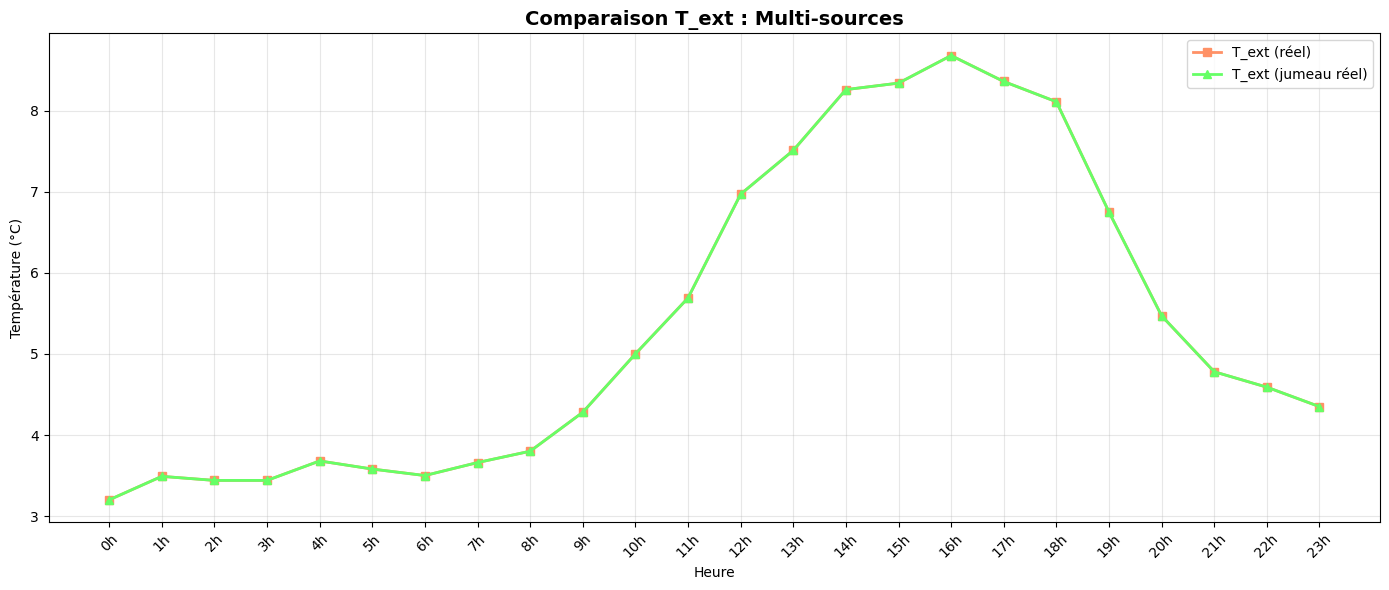

In [42]:
import matplotlib.pyplot as plt
import numpy as np

# Configuration de la figure
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(max(len(df_synthese_visu), len(results_optim_detail), len(df_jn_ref_site), len(df_jn_ref_optim)))

# Dictionnaire de configuration pour automatiser l'affichage et les stats
# Format : [Widget, DataFrame, Label, Couleur, Marker]
raw_configs = [
    (show_optim, results_optim_detail, 'T_ext (optimisation)', '#6694FF', 'o'),
    (show_reel, df_synthese_visu, 'T_ext (réel)', '#FF9166', 's'),
    (show_jn_site, df_jn_ref_site, 'T_ext (jumeau réel)', '#66FF66', '^'),
    (show_jn_optim, df_jn_ref_optim, 'T_ext (jumeau optim)', '#A366FF', 'd') 
]

configs = [
    conf for conf in raw_configs 
    if conf[0] and conf[1] is not None and not conf[1].empty
]

print("--- Statistiques T_ext ---")

for widget, df, label, color, marker in configs:
    if widget.value:  # On vérifie si la case est cochée
        # 1. Tracé
        ax.plot(x, df['T_ext'], marker=marker, linewidth=2, label=label, color=color)
        
        # 2. Print des stats (dynamique)
        print(f"{label: <20} - Mean: {df['T_ext'].mean():.2f}°C, "
              f"Min: {df['T_ext'].min():.2f}°C, Max: {df['T_ext'].max():.2f}°C")

# Personnalisation finale
ax.set_title('Comparaison T_ext : Multi-sources', fontsize=14, fontweight='bold')
ax.set_xlabel('Heure')
ax.set_ylabel('Température (°C)')
ax.set_xticks(x)
ax.set_xticklabels([f"{i}h" for i in range(len(x))], rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 1.2. Q_base (énergie thermique)

--- Statistiques Q_base ---
Q_base (réel)          - Mean: 47.92 kW, Min: 30.00 kW, Max: 60.00 kW, Sum: 1150.00 kWh
Q_base (jumeau réel)   - Mean: 48.08 kW, Min: 34.66 kW, Max: 61.15 kW, Sum: 1153.92 kWh


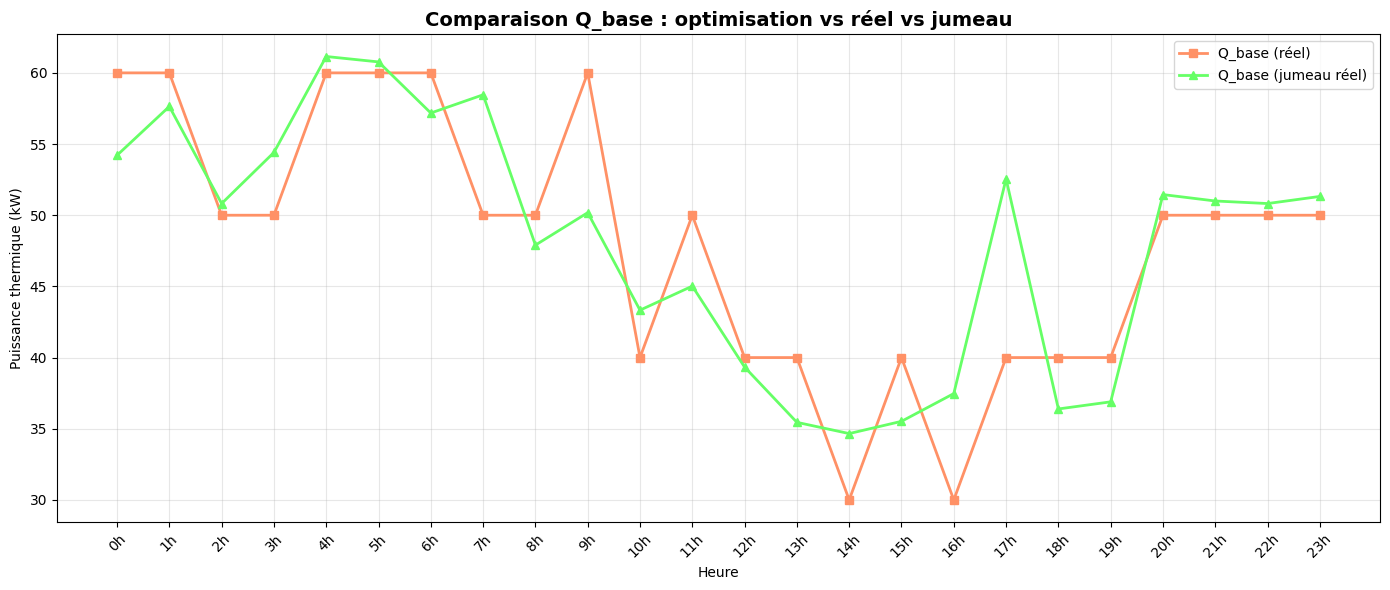

In [43]:
import matplotlib.pyplot as plt
import numpy as np

# Configuration de la figure
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(max(len(df_synthese_visu), len(results_optim_detail), len(df_jn_ref_site), len(df_jn_ref_optim)))

# Dictionnaire de configuration pour automatiser l'affichage et les stats
# Format : [Widget, DataFrame, Label, Couleur, Marker]
raw_configs = [
    (show_optim, results_optim_detail, 'Q_base (optimisation)', '#6694FF', 'o'),
    (show_reel, df_synthese_visu, 'Q_base (réel)', '#FF9166', 's'),
    (show_jn_site, df_jn_ref_site, 'Q_base (jumeau réel)', '#66FF66', '^'),
    (show_jn_optim, df_jn_ref_optim, 'Q_base (jumeau optim)', '#A366FF', 'd') 
]

configs_q = [
    conf for conf in raw_configs 
    if conf[0] and conf[1] is not None and not conf[1].empty
]

print("--- Statistiques Q_base ---")

for widget, df, label, color, marker in configs_q:
    if widget.value:  # On vérifie si la case est cochée dans la cellule du haut
        # 1. Tracé de la courbe
        ax.plot(x, df['Q_base'], marker=marker, linewidth=2, label=label, color=color)
        
        # 2. Affichage des statistiques
        mean_val = df['Q_base'].mean()
        min_val = df['Q_base'].min()
        max_val = df['Q_base'].max()
        sum_val = df['Q_base'].sum()
        
        print(f"{label: <22} - Mean: {mean_val:.2f} kW, Min: {min_val:.2f} kW, "
              f"Max: {max_val:.2f} kW, Sum: {sum_val:.2f} kWh")

# Personnalisation du graphique
ax.set_title('Comparaison Q_base : optimisation vs réel vs jumeau', fontsize=14, fontweight='bold')
ax.set_xlabel('Heure')
ax.set_ylabel('Puissance thermique (kW)')

# Graduation des X (adapté pour 24h ou la longueur du DF)
ax.set_xticks(x)
ax.set_xticklabels([f"{i}h" for i in range(len(x))], rotation=45)

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 1.3. Prix SPOT

--- Statistiques EUR/MWh SPOT ---
EURMWH_SPOT (réel)        - Mean: 134.70 €/MWh, Min: 94.34 €/MWh, Max: 199.98 €/MWh
EURMWH_SPOT (jumeau site) - Mean: 134.70 €/MWh, Min: 94.34 €/MWh, Max: 199.98 €/MWh


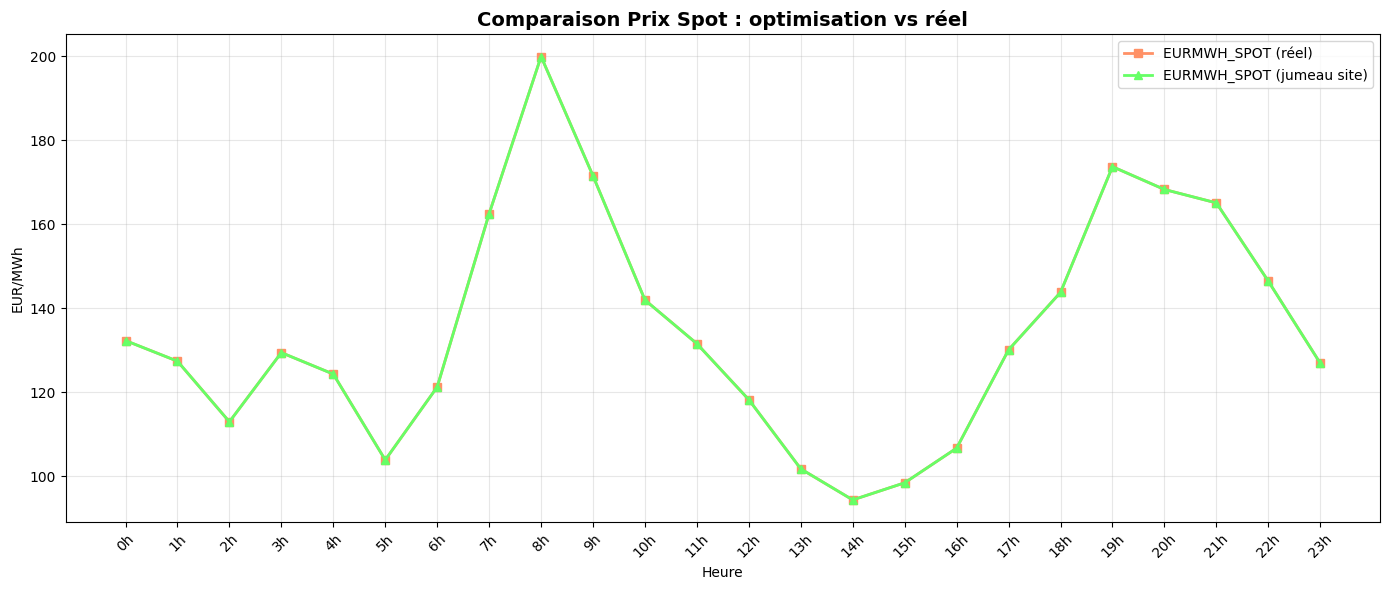

In [44]:
# Configuration de la figure
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(max(len(df_synthese_visu), len(results_optim_detail), len(df_jn_ref_site), len(df_jn_ref_optim)))

# Dictionnaire de configuration pour automatiser l'affichage et les stats
# Format : [Widget, DataFrame, Label, Couleur, Marker]
raw_configs = [
    (show_optim, results_optim_detail, 'EURMWH_SPOT (optimisation)', '#6694FF', 'o'),
    (show_reel, df_synthese_visu, 'EURMWH_SPOT (réel)', '#FF9166', 's'),
    (show_jn_site, df_jn_ref_site, 'EURMWH_SPOT (jumeau site)', '#66FF66', '^'),
    (show_jn_optim, df_jn_ref_optim, 'EURMWH_SPOT (jumeau optim)', '#A366FF', 'd') 
]

configs_p = [
    conf for conf in raw_configs 
    if conf[0] and conf[1] is not None and not conf[1].empty
]

print("--- Statistiques EUR/MWh SPOT ---")

for widget, df, label, color, marker in configs_p:
    # On vérifie si la colonne existe dans le DF et si la case est cochée
    if widget.value and 'EURMWH_SPOT' in df.columns:
        # 1. Tracé
        ax.plot(x, df['EURMWH_SPOT'], marker=marker, linewidth=2, label=label, color=color)
        
        # 2. Stats
        mean_p = df['EURMWH_SPOT'].mean()
        min_p = df['EURMWH_SPOT'].min()
        max_p = df['EURMWH_SPOT'].max()
        
        print(f"{label: <25} - Mean: {mean_p:.2f} €/MWh, Min: {min_p:.2f} €/MWh, Max: {max_p:.2f} €/MWh")

# Personnalisation
ax.set_title('Comparaison Prix Spot : optimisation vs réel', fontsize=14, fontweight='bold')
ax.set_xlabel('Heure')
ax.set_ylabel('EUR/MWh')

ax.set_xticks(x)
ax.set_xticklabels([f"{i}h" for i in range(len(x))], rotation=45)

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 1.4. Prix d'électricité part variable

--- Statistiques EUR/kWh VARIABLE ---
Coût var (réel)      - Mean: 0.2379 €/kWh, Min: 0.1900 €/kWh, Max: 0.3200 €/kWh
Coût var (jumeau réel) - Mean: 0.2379 €/kWh, Min: 0.1900 €/kWh, Max: 0.3200 €/kWh


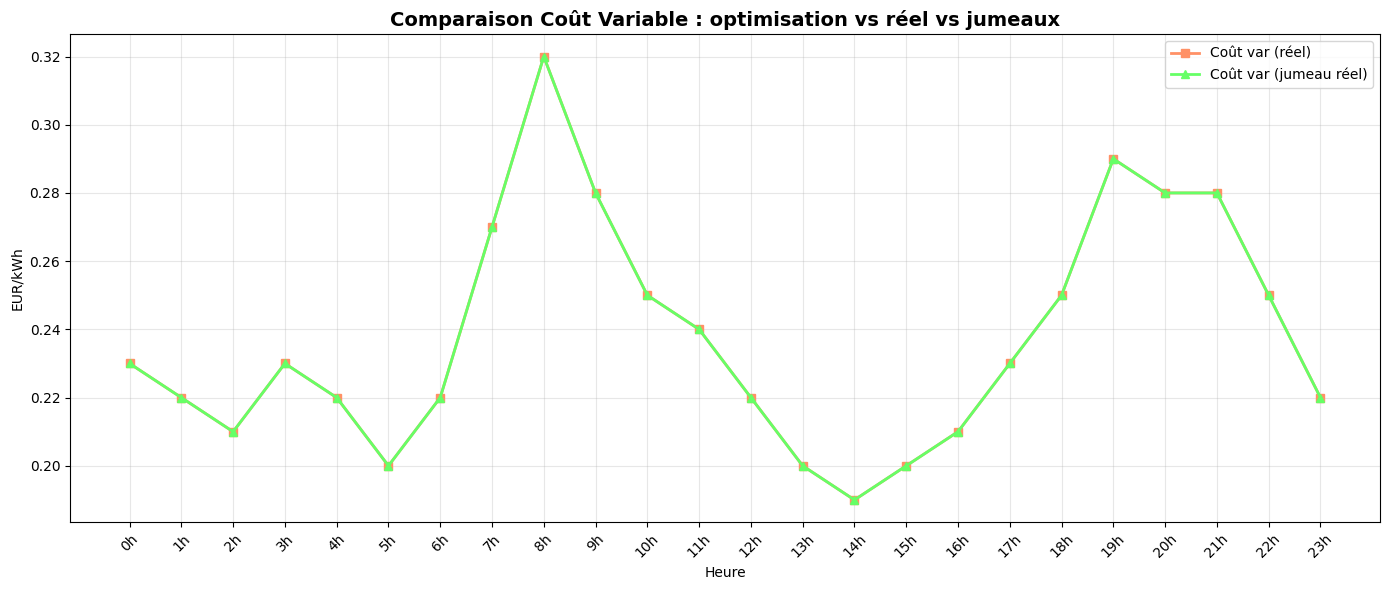

In [45]:
# Configuration de la figure
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(max(len(df_synthese_visu), len(results_optim_detail), len(df_jn_ref_site), len(df_jn_ref_optim)))

# Dictionnaire de configuration pour automatiser l'affichage et les stats
# Format : [Widget, DataFrame, Label, Couleur, Marker]
raw_configs = [
    (show_optim, results_optim_detail, 'Coût var (optimisation)', '#6694FF', 'o'),
    (show_reel, df_synthese_visu, 'Coût var (réel)', '#FF9166', 's'),
    (show_jn_site, df_jn_ref_site, 'Coût var (jumeau réel)', '#66FF66', '^'),
    (show_jn_optim, df_jn_ref_optim, 'Coût var (jumeau optim)', '#A366FF', 'd') 
]

configs_v = [
    conf for conf in raw_configs 
    if conf[0] and conf[1] is not None and not conf[1].empty
]
print("--- Statistiques EUR/kWh VARIABLE ---")

for widget, df, label, color, marker in configs_v:
    # On vérifie si la case est cochée ET si la colonne existe
    if widget.value and 'EURKWH_variable' in df.columns:
        # 1. Tracé
        ax.plot(x, df['EURKWH_variable'], marker=marker, linewidth=2, label=label, color=color)
        
        # 2. Stats
        m_var = df['EURKWH_variable'].mean()
        min_var = df['EURKWH_variable'].min()
        max_var = df['EURKWH_variable'].max()
        
        print(f"{label: <20} - Mean: {m_var:.4f} €/kWh, Min: {min_var:.4f} €/kWh, Max: {max_var:.4f} €/kWh")

# Personnalisation
ax.set_title('Comparaison Coût Variable : optimisation vs réel vs jumeaux', fontsize=14, fontweight='bold')
ax.set_xlabel('Heure')
ax.set_ylabel('EUR/kWh')

ax.set_xticks(x)
ax.set_xticklabels([f"{i}h" for i in range(len(x))], rotation=45)

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 1.5. Température du stock

--- Statistiques Tst ---
Tst (réel)           - Mean: 51.40 °C, Min: 41.20 °C, Max: 59.80 °C
Tst (jumeau réel)    - Mean: 51.62 °C, Min: 42.20 °C, Max: 61.21 °C


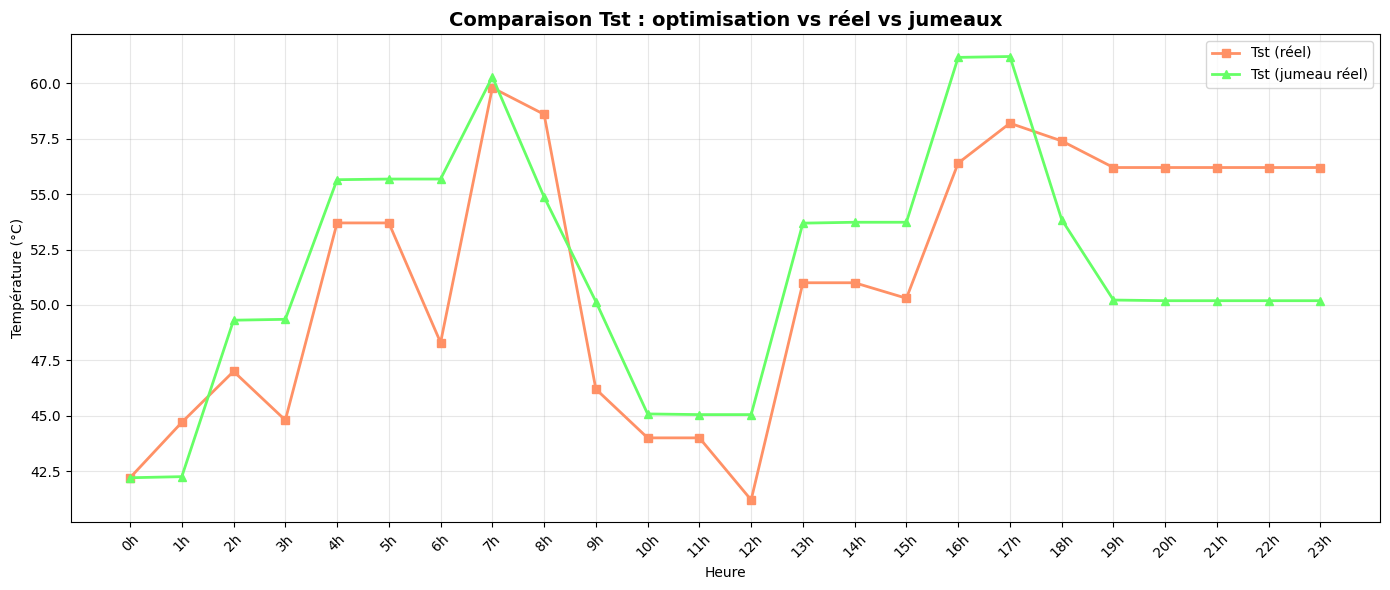



--- Statistiques S_stock ---
S_stock (réel)       - Mean: 211.10 kWh, Min: 151.96 kWh, Max: 259.84 kWh
S_stock (jumeau site) - Mean: 212.42 kWh, Min: 157.76 kWh, Max: 268.03 kWh


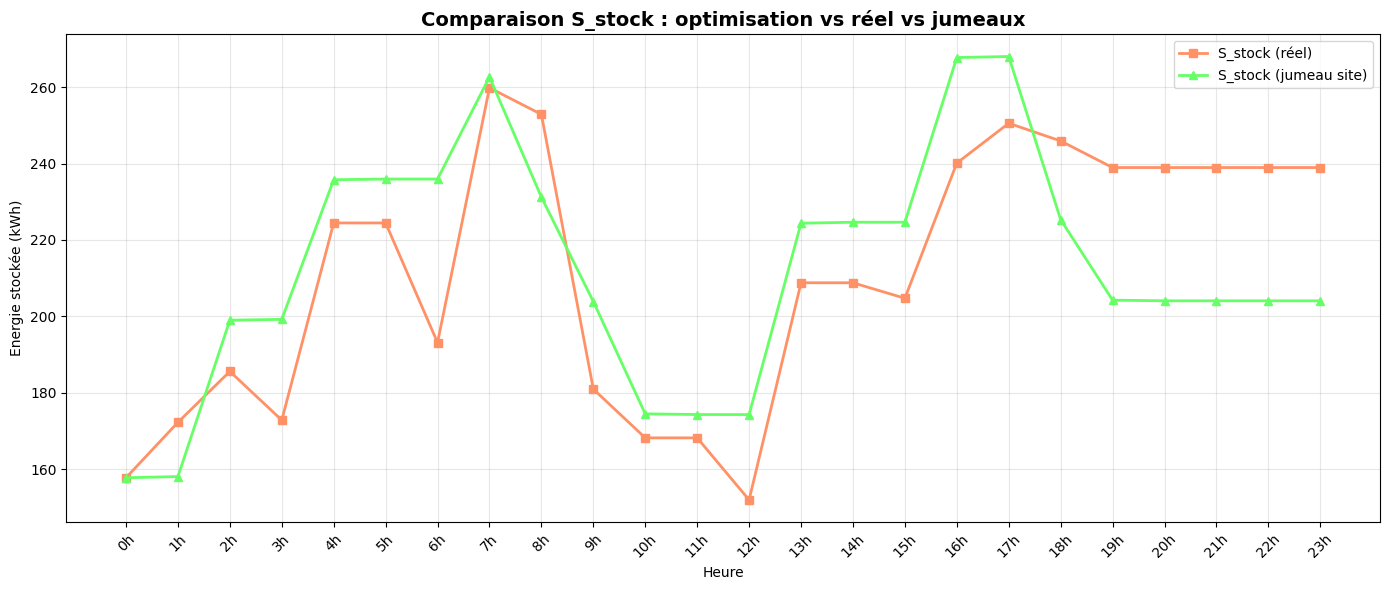

In [46]:
# --- 1. VISUALISATION Tst (Température de stockage) ---
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(max(len(df_synthese_visu), len(results_optim_detail), len(df_jn_ref_site), len(df_jn_ref_optim)))

# Dictionnaire de configuration pour automatiser l'affichage et les stats
# Format : [Widget, DataFrame, Label, Couleur, Marker]
raw_configs = [
    (show_optim, results_optim_detail, 'Tst (optimisation)', '#6694FF', 'o'),
    (show_reel, df_synthese_visu, 'Tst (réel)', '#FF9166', 's'),
    (show_jn_site, df_jn_ref_site, 'Tst (jumeau réel)', '#66FF66', '^'),
    (show_jn_optim, df_jn_ref_optim, 'Tst (jumeau optim)', '#A366FF', 'd') 
]

configs_tst = [
    conf for conf in raw_configs 
    if conf[0] and conf[1] is not None and not conf[1].empty
]

print("--- Statistiques Tst ---")
for widget, df, label, color, marker in configs_tst:
    if widget.value and 'Tst' in df.columns:
        ax.plot(x, df['Tst'], marker=marker, linewidth=2, label=label, color=color)
        print(f"{label: <20} - Mean: {df['Tst'].mean():.2f} °C, Min: {df['Tst'].min():.2f} °C, Max: {df['Tst'].max():.2f} °C")

ax.set_title('Comparaison Tst : optimisation vs réel vs jumeaux', fontsize=14, fontweight='bold')
ax.set_xlabel('Heure')
ax.set_ylabel('Température (°C)')
ax.set_xticks(x)
ax.set_xticklabels([f"{i}h" for i in range(len(x))], rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*50 + "\n")

# --- 2. VISUALISATION S_stock (Énergie stockée) ---
fig, ax = plt.subplots(figsize=(14, 6))

configs_s = [
    (show_optim, results_optim_detail, 'S_stock (optimisation)', '#6694FF', 'o'),
    (show_reel, df_synthese_visu, 'S_stock (réel)', '#FF9166', 's'),
    (show_jn_site, df_jn_ref_site, 'S_stock (jumeau site)', '#66FF66', '^'),
    (show_jn_optim, df_jn_ref_optim, 'S_stock (jumeau optim)', '#A366FF', 'd')
]

print("--- Statistiques S_stock ---")
for widget, df, label, color, marker in configs_s:
    if widget.value and 'S_stock' in df.columns:
        ax.plot(x, df['S_stock'], marker=marker, linewidth=2, label=label, color=color)
        print(f"{label: <20} - Mean: {df['S_stock'].mean():.2f} kWh, Min: {df['S_stock'].min():.2f} kWh, Max: {df['S_stock'].max():.2f} kWh")

ax.set_title('Comparaison S_stock : optimisation vs réel vs jumeaux', fontsize=14, fontweight='bold')
ax.set_xlabel('Heure')
ax.set_ylabel('Energie stockée (kWh)')
ax.set_xticks(x)
ax.set_xticklabels([f"{i}h" for i in range(len(x))], rotation=45)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 1.6. Consommation électrique totale

--- Statistiques Elec_tot ---
Elec_tot (réel)      - Mean: 28.49 kWh, Min: 1.33 kWh, Max: 66.42 kWh, Total: 683.83 kWh
Elec_tot (jumeau réel) - Mean: 23.77 kWh, Min: 1.08 kWh, Max: 66.52 kWh, Total: 570.41 kWh


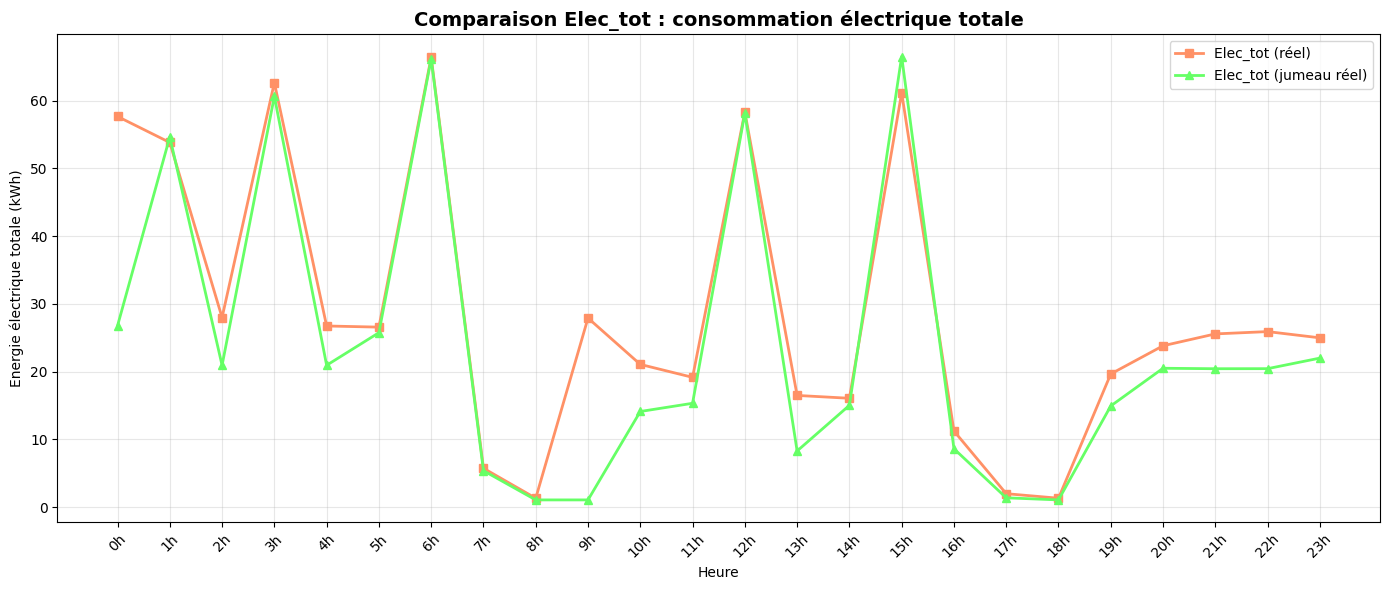

In [47]:
# --- VISUALISATION Elec_tot (Line Plot) ---
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(max(len(df_synthese_visu), len(results_optim_detail), len(df_jn_ref_site), len(df_jn_ref_optim)))

# Dictionnaire de configuration pour automatiser l'affichage et les stats
# Format : [Widget, DataFrame, Label, Couleur, Marker]
raw_configs = [
    (show_optim, results_optim_detail, 'Elec_tot (optimisation)', '#6694FF', 'o'),
    (show_reel, df_synthese_visu, 'Elec_tot (réel)', '#FF9166', 's'),
    (show_jn_site, df_jn_ref_site, 'Elec_tot (jumeau réel)', '#66FF66', '^'),
    (show_jn_optim, df_jn_ref_optim, 'Elec_tot (jumeau optim)', '#A366FF', 'd') 
]

configs_elec = [
    conf for conf in raw_configs 
    if conf[0] and conf[1] is not None and not conf[1].empty
]

print("--- Statistiques Elec_tot ---")

for widget, df, label, color, marker in configs_elec:
    # On vérifie si la case est cochée et si la colonne existe
    if widget.value and 'Elec_tot' in df.columns:
        # 1. Tracé de la ligne
        ax.plot(x, df['Elec_tot'], marker=marker, linewidth=2, label=label, color=color)
        
        # 2. Affichage des statistiques (Moyenne, Min, Max et Somme totale)
        print(f"{label: <20} - Mean: {df['Elec_tot'].mean():.2f} kWh, "
              f"Min: {df['Elec_tot'].min():.2f} kWh, Max: {df['Elec_tot'].max():.2f} kWh, "
              f"Total: {df['Elec_tot'].sum():.2f} kWh")

# Personnalisation du graphique
ax.set_title('Comparaison Elec_tot : consommation électrique totale', fontsize=14, fontweight='bold')
ax.set_xlabel('Heure')
ax.set_ylabel('Energie électrique totale (kWh)')

ax.set_xticks(x)
ax.set_xticklabels([f"{i}h" for i in range(len(x))], rotation=45)

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 1.7. Coût total

--- Statistiques Cost_hour ---
Coût (réel)            - Mean: 6.79 €, Min: 0.60 €, Max: 15.13 €, Total: 163.06 €
Coût (jumeau réel)     - Mean: 5.66 €, Min: 0.56 €, Max: 14.85 €, Total: 135.90 €


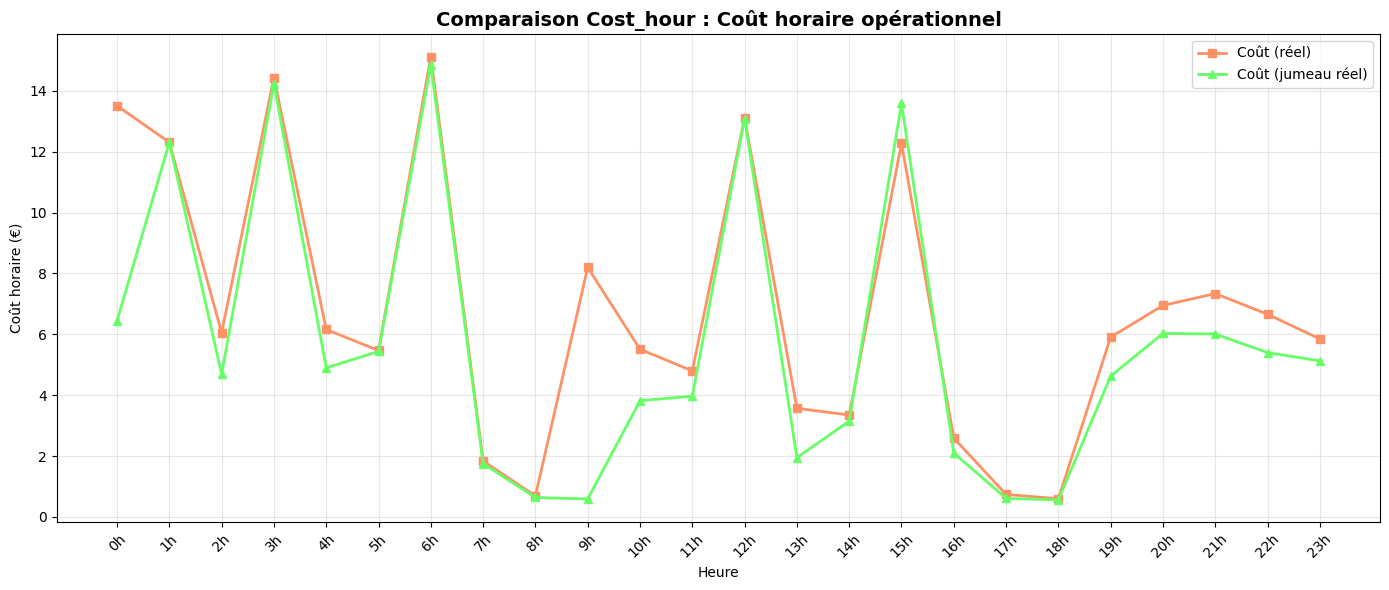

In [48]:
# --- VISUALISATION Cost_hour (Line Plot) ---
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(max(len(df_synthese_visu), len(results_optim_detail), len(df_jn_ref_site), len(df_jn_ref_optim)))

# Dictionnaire de configuration pour automatiser l'affichage et les stats
# Format : [Widget, DataFrame, Label, Couleur, Marker]
raw_configs = [
    (show_optim, results_optim_detail, 'Coût (optimisation)', '#6694FF', 'o'),
    (show_reel, df_synthese_visu, 'Coût (réel)', '#FF9166', 's'),
    (show_jn_site, df_jn_ref_site, 'Coût (jumeau réel)', '#66FF66', '^'),
    (show_jn_optim, df_jn_ref_optim, 'Coût (jumeau optim)', '#A366FF', 'd') 
]

configs_cost = [
    conf for conf in raw_configs 
    if conf[0] and conf[1] is not None and not conf[1].empty
]

print("--- Statistiques Cost_hour ---")

for widget, df, label, color, marker in configs_cost:
    # Vérification si la case est cochée et si la colonne existe dans le DataFrame
    if widget.value and 'Cost_hour' in df.columns:
        # 1. Tracé de la ligne
        ax.plot(x, df['Cost_hour'], marker=marker, linewidth=2, label=label, color=color)
        
        # 2. Statistiques
        c_mean = df['Cost_hour'].mean()
        c_min = df['Cost_hour'].min()
        c_max = df['Cost_hour'].max()
        c_sum = df['Cost_hour'].sum()
        
        print(f"{label: <22} - Mean: {c_mean:.2f} €, Min: {c_min:.2f} €, "
              f"Max: {c_max:.2f} €, Total: {c_sum:.2f} €")

# Personnalisation du graphique
ax.set_title('Comparaison Cost_hour : Coût horaire opérationnel', fontsize=14, fontweight='bold')
ax.set_xlabel('Heure')
ax.set_ylabel('Coût horaire (€)')

ax.set_xticks(x)
ax.set_xticklabels([f"{i}h" for i in range(len(x))], rotation=45)

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()